In [ ]:
!pip install pandas numpy matplotlib seaborn tqdm pyarrow gdown geopandas shapely -q

print('Semua dependency berhasil diinstall!')
print()

import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns

print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn : {sns.__version__}')

Semua dependency berhasil diinstall!

pandas  : 2.2.2
numpy   : 2.0.2
matplotlib: 3.10.0
seaborn : 0.13.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print('Google Drive berhasil di-mount di /content/drive')

Mounted at /content/drive
Google Drive berhasil di-mount di /content/drive


In [ ]:
import os

NAMA_FOLDER_DI_DRIVE = 'DARVIN/data/gfw_sar'
FOLDER_GFW_SAR = f'/content/drive/MyDrive/{NAMA_FOLDER_DI_DRIVE}/'


FOLDER_OUTPUT  = f'/content/drive/MyDrive/{NAMA_FOLDER_DI_DRIVE}/output/'

PREFILTER_LAT_MIN = -4.5
PREFILTER_LAT_MAX = 8.0
PREFILTER_LON_MIN = 102.5
PREFILTER_LON_MAX = 111.5


TAHUN_MULAI = 2023
TAHUN_AKHIR = 2025

os.makedirs(FOLDER_OUTPUT, exist_ok=True)

if os.path.exists(FOLDER_GFW_SAR):
    print(f'Folder input ditemukan : {FOLDER_GFW_SAR}')
    print(f'Folder output siap     : {FOLDER_OUTPUT}')
    print()
    print(f'Kotak pre-filter kasar (BUKAN batas resmi WPP 711, hanya mempercepat baca data):')
    print(f'Latitude  : {PREFILTER_LAT_MIN}° – {PREFILTER_LAT_MAX}° LU')
    print(f'Longitude : {PREFILTER_LON_MIN}° – {PREFILTER_LON_MAX}° BT')
    print(f'Batas resmi WPP 711 (polygon BIG) di-load & digunakan langsung di Cell 4.')
else:
    print(f'FOLDER TIDAK DITEMUKAN: {FOLDER_GFW_SAR}')
    print(f'Cek kembali nilai NAMA_FOLDER_DI_DRIVE di atas!')
    print(f'Jalankan cell berikut untuk lihat isi Drive kamu:')
    print(f'!ls /content/drive/MyDrive/')

Folder input ditemukan : /content/drive/MyDrive/DARVIN/data/gfw_sar/
Folder output siap     : /content/drive/MyDrive/DARVIN/data/gfw_sar/output/

Kotak pre-filter kasar (BUKAN batas resmi WPP 711, hanya mempercepat baca data):
Latitude  : -4.5° – 8.0° LU
Longitude : 102.5° – 111.5° BT
Batas resmi WPP 711 (polygon BIG) di-load & digunakan langsung di Cell 4.


In [ ]:
import glob
import re

all_files = sorted(glob.glob(FOLDER_GFW_SAR + 'sar_vessel_detections_*.csv'))

print(f'Total file CSV ditemukan: {len(all_files)}')
print()

pipev_old  = [f for f in all_files if 'pipev20231026' in f]
pipev3     = [f for f in all_files if 'pipev3' in f]
pipev4     = [f for f in all_files if 'pipev4' in f]
other      = [f for f in all_files if f not in pipev_old + pipev3 + pipev4]

print(f'  Pipeline v20231026 (Jan 2023 – Nov 2024) : {len(pipev_old)} file')
print(f'  Pipeline v3        (Nov 2024 – Feb 2026) : {len(pipev3)} file')
print(f'  Pipeline v4        (Feb 2026+)           : {len(pipev4)} file')
print(f'  Lainnya                                  : {len(other)} file')
print()

print('Daftar file (urutan kronologis):')

total_size_mb = 0
for i, f in enumerate(all_files, 1):
    fname    = os.path.basename(f)
    size_mb  = os.path.getsize(f) / (1024 * 1024)
    total_size_mb += size_mb

    match    = re.search(r'_(\d{6})(\.csv)?$', fname)
    yyyymm   = match.group(1) if match else '??????'
    pipeline = 'v20231026' if 'v20231026' in fname else ('v3' if 'pipev3' in fname else 'v4')
    print(f'  [{i:02d}] {yyyymm}  {pipeline:<12}  {size_mb:>7.1f} MB   {fname[:55]}')


print(f'  TOTAL SIZE: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)')

Total file CSV ditemukan: 38

  Pipeline v20231026 (Jan 2023 – Nov 2024) : 24 file
  Pipeline v3        (Nov 2024 – Feb 2026) : 14 file
  Pipeline v4        (Feb 2026+)           : 0 file
  Lainnya                                  : 0 file

Daftar file (urutan kronologis):
  [01] 202301  v20231026        43.1 MB   sar_vessel_detections_pipev20231026_202301.csv
  [02] 202302  v20231026        38.7 MB   sar_vessel_detections_pipev20231026_202302.csv
  [03] 202303  v20231026        49.2 MB   sar_vessel_detections_pipev20231026_202303.csv
  [04] 202304  v20231026        43.1 MB   sar_vessel_detections_pipev20231026_202304.csv
  [05] 202305  v20231026        42.1 MB   sar_vessel_detections_pipev20231026_202305.csv
  [06] 202306  v20231026        38.0 MB   sar_vessel_detections_pipev20231026_202306.csv
  [07] 202307  v20231026        39.5 MB   sar_vessel_detections_pipev20231026_202307.csv
  [08] 202308  v20231026        44.2 MB   sar_vessel_detections_pipev20231026_202308.csv
  [09] 202309 

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import requests
import geopandas as gpd
from shapely.vectorized import contains as shapely_contains
from tqdm import tqdm

KOLOM_DIPAKAI = [
    'scene_id',
    'timestamp',
    'lat',
    'lon',
    'presence_score',
    'length_m',
    'fishing_score',
    'matched_category',
    'matching_score',
    'mmsi',
]

os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"

WPP711_GEOJSON_PATH = "wpp711_big_resmi.geojson"

BIG_URL = "https://kspservices.big.go.id/satupeta/rest/services/PUBLIK/SUMBER_DAYA_ALAM_DAN_LINGKUNGAN/MapServer/21/query"
BIG_HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}
BIG_PARAMS = {
    "where": "namobj = 'WPP-RI 711'",
    "outFields": "*",
    "f": "geojson"
}

if not os.path.exists(WPP711_GEOJSON_PATH):
    print("Mengunduh batas WPP 711 resmi dari BIG (Portal Satu Peta)...")
    response = requests.get(BIG_URL, params=BIG_PARAMS, headers=BIG_HEADERS, timeout=90)
    print(f"Status code: {response.status_code}")
    response.raise_for_status()
    with open(WPP711_GEOJSON_PATH, "w") as f:
        f.write(response.text)
    print("Berhasil diunduh & disimpan.")
else:
    print(f"File GeoJSON sudah ada: {WPP711_GEOJSON_PATH}, skip download.")

wpp_711_only = gpd.read_file(WPP711_GEOJSON_PATH, engine="pyogrio")

if wpp_711_only.crs is None:
    wpp_711_only = wpp_711_only.set_crs("EPSG:4326", allow_override=True)

if len(wpp_711_only) == 0:
    raise ValueError("Tidak ada fitur dengan namobj = 'WPP-RI 711' pada response BIG.")

wpp711_geom = wpp_711_only.geometry.union_all()

luas_km2 = gpd.GeoSeries([wpp711_geom], crs="EPSG:4326").to_crs("EPSG:3395").area.iloc[0] / 1e6
minx, miny, maxx, maxy = wpp711_geom.bounds

print()
print(f'Sumber          : BIG - Portal Satu Peta (layer "Peta Wilayah Pengelolaan Perikanan RI")')
print(f'Dasar hukum     : Permen KP No. 18/PERMEN-KP/2014')
print(f'Jumlah fitur    : {len(wpp_711_only)}')
print(f'Nama wilayah    : {wpp_711_only["namobj"].iloc[0]}')
print(f'Perairan        : {wpp_711_only["perairan"].iloc[0]}')
print(f'Valid geometry  : {wpp711_geom.is_valid}')
print(f'Luas area       : {luas_km2:,.0f} km²')
print(f'Bounding box    : {minx:.2f}–{maxx:.2f}°BT, {miny:.2f}–{maxy:.2f}°LU')
print()

results     = []
stats_list  = []
error_files = []

print(f'Memulai proses load & filter...')
print(f'Filter: point-in-polygon pakai polygon resmi WPP 711 dari BIG')
print(f'Pre-filter kasar (bounding box hasil polygon BIG): Lat [{miny:.2f}, {maxy:.2f}] | Lon [{minx:.2f}, {maxx:.2f}]')
print(f'Total file  : {len(all_files)}')
print()

for f in tqdm(all_files, desc='Memproses CSV'):
    fname = os.path.basename(f)
    try:
        df_raw = pd.read_csv(f, usecols=lambda c: c in KOLOM_DIPAKAI, low_memory=False)
        total_global = len(df_raw)

        mask_box = (
            (df_raw['lat'] >= miny) &
            (df_raw['lat'] <= maxy) &
            (df_raw['lon'] >= minx) &
            (df_raw['lon'] <= maxx)
        )
        df_box = df_raw[mask_box].copy()

        if len(df_box) > 0:
            mask_poly = shapely_contains(
                wpp711_geom,
                df_box['lon'].values,
                df_box['lat'].values
            )
            df_natuna = df_box[mask_poly].copy()
        else:
            df_natuna = df_box

        total_natuna = len(df_natuna)

        match = re.search(r'_(\d{6})(\.csv)?$', fname)
        yyyymm = match.group(1) if match else 'unknown'

        if 'pipev20231026' in fname:
            pipeline = 'v20231026'
        elif 'pipev3' in fname:
            pipeline = 'v3'
        elif 'pipev4' in fname:
            pipeline = 'v4'
        else:
            pipeline = 'unknown'

        df_natuna['source_yyyymm'] = yyyymm
        df_natuna['pipeline_ver']  = pipeline
        df_natuna['source_file']   = fname

        results.append(df_natuna)

        stats_list.append({
            'file'          : fname,
            'yyyymm'        : yyyymm,
            'pipeline'      : pipeline,
            'total_global'  : total_global,
            'total_natuna'  : total_natuna,
            'pct_natuna'    : round(total_natuna / total_global * 100, 3) if total_global > 0 else 0
        })

    except Exception as e:
        error_files.append({'file': fname, 'error': str(e)})
        print(f'\n ERROR di {fname}: {e}')

print()

if not results:
    raise ValueError('Tidak ada data yang berhasil dimuat. Cek path folder dan isi file CSV.')
df_final = pd.concat(results, ignore_index=True)

print(f'Selesai!')
print(f'Total baris di dataset WPP 711 2023-2025: {len(df_final):,}')
print(f'Total kolom                             : {len(df_final.columns)}')
if error_files:
    print(f'File gagal diproses                 : {len(error_files)}')

Mengunduh batas WPP 711 resmi dari BIG (Portal Satu Peta)...
Status code: 200
Berhasil diunduh & disimpan.

Sumber          : BIG - Portal Satu Peta (layer "Peta Wilayah Pengelolaan Perikanan RI")
Dasar hukum     : Permen KP No. 18/PERMEN-KP/2014
Jumlah fitur    : 1
Nama wilayah    : WPP-RI 711
Perairan        : Meliputi Perairan Selat Karimata, Laut Natuna dan Laut Cina Selatan
Valid geometry  : True
Luas area       : 661,954 km²
Bounding box    : 102.90–111.05°BT, -4.16–7.74°LU

Memulai proses load & filter...
Filter: point-in-polygon pakai polygon resmi WPP 711 dari BIG
Pre-filter kasar (bounding box hasil polygon BIG): Lat [-4.16, 7.74] | Lon [102.90, 111.05]
Total file  : 38



Memproses CSV:   0%|          | 0/38 [00:00<?, ?it/s]/tmp/ipykernel_1538/4112152735.py:97: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask_poly = shapely_contains(
Memproses CSV:   3%|▎         | 1/38 [00:02<01:22,  2.22s/it]/tmp/ipykernel_1538/4112152735.py:97: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask_poly = shapely_contains(
Memproses CSV:   5%|▌         | 2/38 [00:04<01:26,  2.40s/it]/tmp/ipykernel_1538/4112152735.py:97: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask_poly = shapely_contains(
Memproses CSV:   8%|▊         | 3/38 [00:07<01:34,  2.69s/it]/tmp/ipy


Selesai!
Total baris di dataset WPP 711 2023-2025: 157,592
Total kolom                             : 13


In [ ]:
df_final['timestamp'] = pd.to_datetime(df_final['timestamp'], errors='coerce')

df_final['year']        = df_final['timestamp'].dt.year
df_final['month']       = df_final['timestamp'].dt.month
df_final['hour_utc']    = df_final['timestamp'].dt.hour
df_final['day_of_week'] = df_final['timestamp'].dt.dayofweek

df_final['season'] = df_final['month'].map({
    1: 1, 2: 1, 3: 1,
    4: 2, 5: 2, 6: 2,
    7: 3, 8: 3, 9: 3,
    10: 4, 11: 4, 12: 4
})

df_final['ais_matched'] = (
    df_final['matched_category'].fillna('unmatched') != 'unmatched'
).astype(int)

for col in ['lat', 'lon', 'presence_score', 'fishing_score', 'length_m', 'matching_score']:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

sebelum = len(df_final)
df_final = df_final[df_final['presence_score'] >= 0.7].copy()
sesudah  = len(df_final)

df_final = df_final.drop_duplicates(subset=['scene_id', 'lat', 'lon']).copy()
setelah_dedup = len(df_final)

df_final = df_final.reset_index(drop=True)

print(f'   Sebelum filter presence_score < 0.7 : {sebelum:,} baris')
print(f'   Setelah filter                      : {sesudah:,} baris')
print(f'   Setelah drop duplikat               : {setelah_dedup:,} baris')
print()
print('Cleaning selesai!')
print()
print('Info dataset final:')
df_final.info()

   Sebelum filter presence_score < 0.7 : 157,592 baris
   Setelah filter                      : 157,592 baris
   Setelah drop duplikat               : 153,523 baris

Cleaning selesai!

Info dataset final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153523 entries, 0 to 153522
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   scene_id          153523 non-null  object             
 1   timestamp         153523 non-null  datetime64[ns, UTC]
 2   lat               153523 non-null  float64            
 3   lon               153523 non-null  float64            
 4   presence_score    153523 non-null  float64            
 5   length_m          153523 non-null  float64            
 6   mmsi              101384 non-null  float64            
 7   matching_score    153523 non-null  float64            
 8   fishing_score     152975 non-null  float64            
 9   matched_category  1

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

df_stats = pd.DataFrame(stats_list)
print('Statistik deteksi per bulan (Natuna only):')
print(df_stats[['yyyymm', 'pipeline', 'total_global', 'total_natuna', 'pct_natuna']].to_string(index=False))
print()
print(f'Rata-rata deteksi Natuna per bulan : {df_stats["total_natuna"].mean():.0f}')
print(f'Min deteksi per bulan              : {df_stats["total_natuna"].min()}')
print(f'Max deteksi per bulan              : {df_stats["total_natuna"].max()}')

Statistik deteksi per bulan (Natuna only):
 yyyymm  pipeline  total_global  total_natuna  pct_natuna
 202301 v20231026        232178          5645       2.431
 202302 v20231026        207997          4120       1.981
 202303 v20231026        264057          5129       1.942
 202304 v20231026        230619          3748       1.625
 202305 v20231026        226166          5193       2.296
 202306 v20231026        203704          5934       2.913
 202307 v20231026        212136          3415       1.610
 202308 v20231026        236329          3665       1.551
 202309 v20231026        255152          4016       1.574
 202310 v20231026        183836          3610       1.964
 202311 v20231026        221710          3566       1.608
 202312 v20231026        233535          4132       1.769
 202401 v20231026        216234          3615       1.672
 202402 v20231026        191043          2988       1.564
 202403 v20231026        244407          4078       1.669
 202404 v20231026        2336

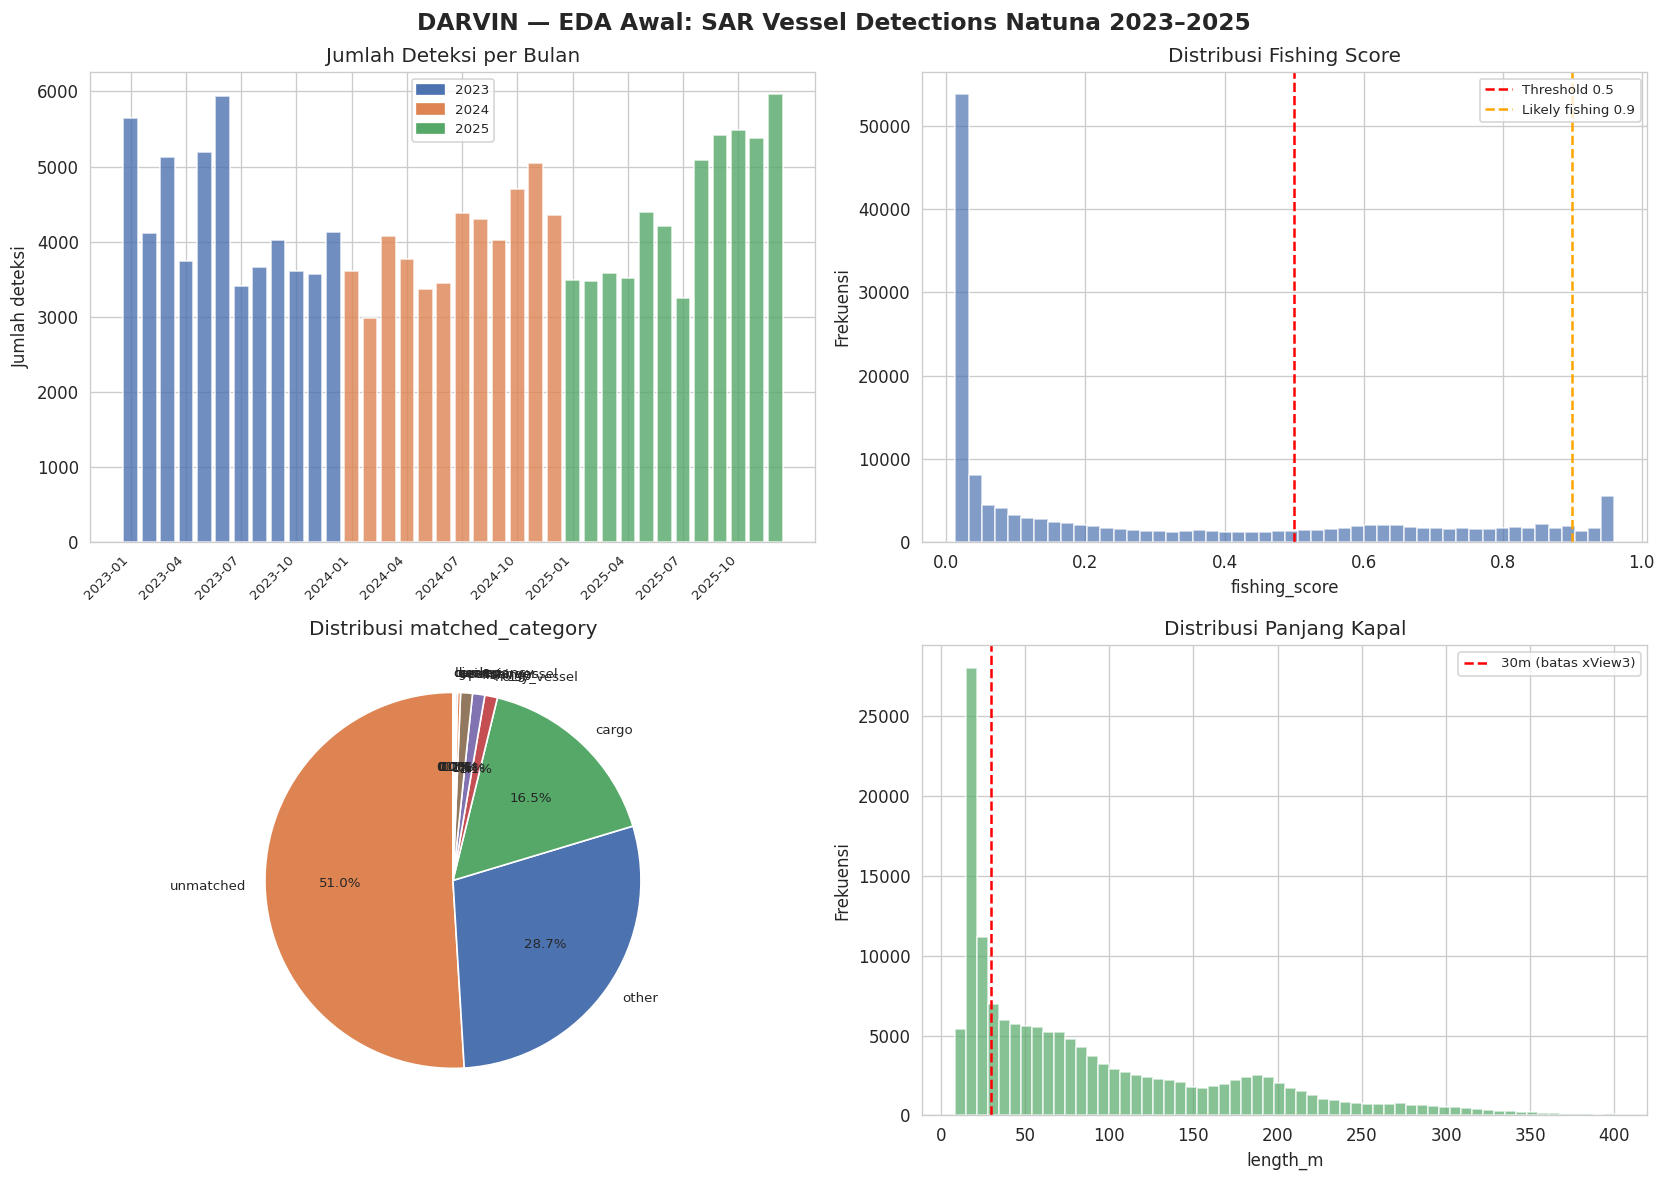

Plot tersimpan di folder output


In [ ]:
import os

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DARVIN — EDA Awal: SAR Vessel Detections Natuna 2023–2025', fontsize=14, fontweight='bold')

ax1 = axes[0, 0]
monthly = df_final.groupby(['year', 'month']).size().reset_index(name='count')
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)
colors = monthly['year'].map({2023: '#4C72B0', 2024: '#DD8452', 2025: '#55A868'})
ax1.bar(range(len(monthly)), monthly['count'], color=colors, alpha=0.8)
ax1.set_title('Jumlah Deteksi per Bulan')
ax1.set_ylabel('Jumlah deteksi')
ax1.set_xticks(range(0, len(monthly), 3))
ax1.set_xticklabels(monthly['period'].iloc[::3], rotation=45, ha='right', fontsize=8)

from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color='#4C72B0', label='2023'),
    Patch(color='#DD8452', label='2024'),
    Patch(color='#55A868', label='2025')
], fontsize=8)


ax2 = axes[0, 1]
df_final['fishing_score'].dropna().hist(bins=50, ax=ax2, color='#4C72B0', alpha=0.7, edgecolor='white')
ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold 0.5')
ax2.axvline(x=0.9, color='orange', linestyle='--', linewidth=1.5, label='Likely fishing 0.9')
ax2.set_title('Distribusi Fishing Score')
ax2.set_xlabel('fishing_score')
ax2.set_ylabel('Frekuensi')
ax2.legend(fontsize=8)


ax3 = axes[1, 0]
matched_counts = df_final['matched_category'].value_counts()
colors_pie = ['#DD8452', '#4C72B0', '#55A868', '#C44E52', '#8172B2', '#937860']
ax3.pie(matched_counts.values, labels=matched_counts.index,
        autopct='%1.1f%%', colors=colors_pie[:len(matched_counts)],
        startangle=90, textprops={'fontsize': 8})
ax3.set_title('Distribusi matched_category')

ax4 = axes[1, 1]
df_final['length_m'].dropna().clip(0, 400).hist(bins=60, ax=ax4, color='#55A868', alpha=0.7, edgecolor='white')
ax4.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='30m (batas xView3)')
ax4.set_title('Distribusi Panjang Kapal')
ax4.set_xlabel('length_m')
ax4.set_ylabel('Frekuensi')
ax4.legend(fontsize=8)

plt.tight_layout()
os.makedirs(FOLDER_OUTPUT, exist_ok=True)
plt.savefig(FOLDER_OUTPUT + 'DARVIN_EDA_awal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan di folder output')

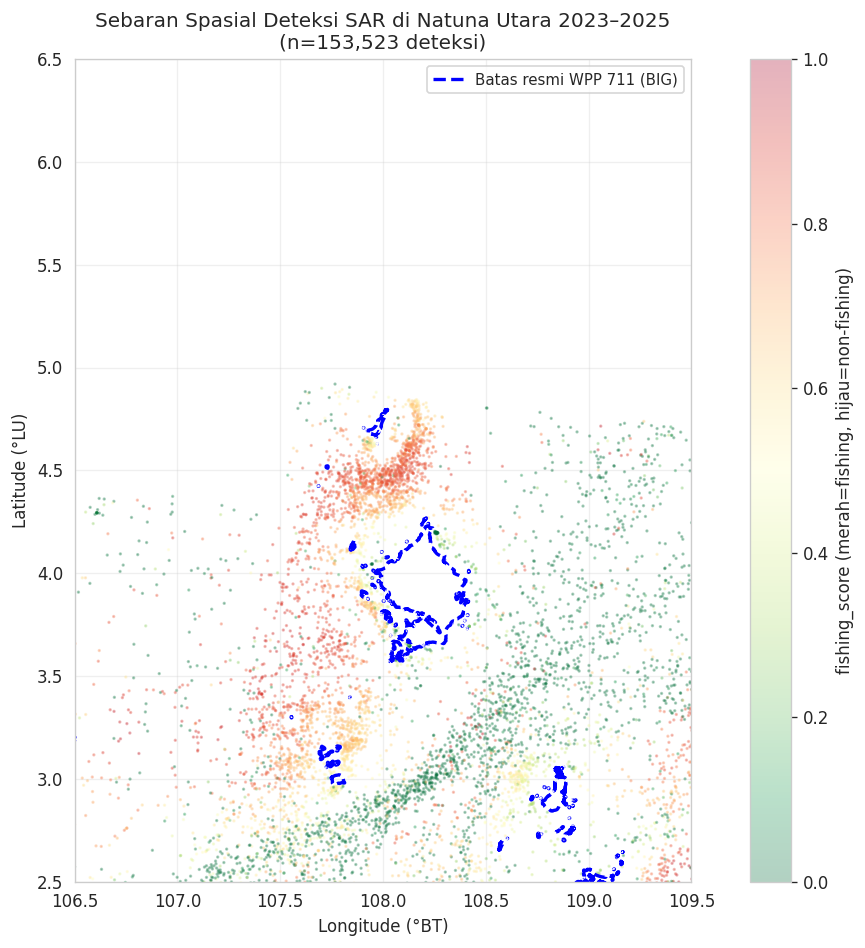

Peta tersimpan di folder output


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

scatter = ax.scatter(
    df_final['lon'],
    df_final['lat'],
    c=df_final['fishing_score'],
    cmap='RdYlGn_r',
    s=1,
    alpha=0.3,
    vmin=0, vmax=1
)

# Outline batas resmi WPP 711 (polygon asli dari BIG, BUKAN kotak persegi)
wpp_711_only.boundary.plot(ax=ax, color='blue', linewidth=2, linestyle='--', label='Batas resmi WPP 711 (BIG)')

plt.colorbar(scatter, ax=ax, label='fishing_score (merah=fishing, hijau=non-fishing)')
ax.set_xlabel('Longitude (°BT)')
ax.set_ylabel('Latitude (°LU)')
ax.set_title(f'Sebaran Spasial Deteksi SAR di Natuna Utara 2023–2025\n(n={len(df_final):,} deteksi)', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(106.5, 109.5)
ax.set_ylim(2.5, 6.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FOLDER_OUTPUT + 'DARVIN_peta_deteksi_natuna.png', dpi=150, bbox_inches='tight')
plt.show()
print('Peta tersimpan di folder output')

In [ ]:
print('RINGKASAN DATASET DARVIN — NATUNA 2023-2025')

total = len(df_final)
unmatched = (df_final['matched_category'] == 'unmatched').sum()
likely_fishing = (df_final['fishing_score'] >= 0.9).sum()
large_vessel = (df_final['length_m'] >= 30).sum()

print(f'  Total deteksi             : {total:>10,}')
print(f'  Unmatched (dark vessels)  : {unmatched:>10,}  ({unmatched/total*100:.1f}%)')
print(f'  Likely fishing (>=0.9)    : {likely_fishing:>10,}  ({likely_fishing/total*100:.1f}%)')
print(f'  Kapal >= 30m              : {large_vessel:>10,}  ({large_vessel/total*100:.1f}%)')
print()

print('  Deteksi per tahun:')
for yr in [2023, 2024, 2025]:
    n = (df_final['year'] == yr).sum()
    print(f'    {yr}: {n:>8,} deteksi')
print()

print('  Statistik fishing_score:')
fs = df_final['fishing_score'].dropna()
print(f'    Mean   : {fs.mean():.3f}')
print(f'    Median : {fs.median():.3f}')
print(f'    Std    : {fs.std():.3f}')
print()

print('  Statistik length_m:')
lm = df_final['length_m'].dropna()
print(f'    Mean   : {lm.mean():.1f} m')
print(f'    Median : {lm.median():.1f} m')
print(f'    Min    : {lm.min():.1f} m')
print(f'    Max    : {lm.max():.1f} m')
print()

print('  Jumlah scene Sentinel-1 unik :')
print(f'    Total  : {df_final["scene_id"].nunique():>8,} scene')
per_year = df_final.groupby('year')['scene_id'].nunique()
for yr, n in per_year.items():
    print(f'    {yr}   : {n:>8,} scene')


RINGKASAN DATASET DARVIN — NATUNA 2023-2025
  Total deteksi             :    153,523
  Unmatched (dark vessels)  :     78,229  (51.0%)
  Likely fishing (>=0.9)    :      9,043  (5.9%)
  Kapal >= 30m              :    106,937  (69.7%)

  Deteksi per tahun:
    2023:   52,173 deteksi
    2024:   48,088 deteksi
    2025:   53,262 deteksi

  Statistik fishing_score:
    Mean   : 0.298
    Median : 0.127
    Std    : 0.324

  Statistik length_m:
    Mean   : 91.4 m
    Median : 63.7 m
    Min    : 8.8 m
    Max    : 434.0 m

  Jumlah scene Sentinel-1 unik :
    Total  :    2,136 scene
    2023   :      713 scene
    2024   :      709 scene
    2025   :      714 scene


In [ ]:
import time

output_csv     = FOLDER_OUTPUT + 'DARVIN_natuna_SAR_2023_2025.csv'
output_parquet = FOLDER_OUTPUT + 'DARVIN_natuna_SAR_2023_2025.parquet'

t0 = time.time()
df_final.to_csv(output_csv, index=False)
t1 = time.time()
size_csv = os.path.getsize(output_csv) / (1024*1024)
print(f'CSV tersimpan     : {output_csv}')
print(f'Ukuran            : {size_csv:.1f} MB')
print(f'Waktu simpan      : {t1-t0:.1f} detik')
print()

t0 = time.time()
df_final.to_parquet(output_parquet, index=False, engine='pyarrow')
t1 = time.time()
size_pq = os.path.getsize(output_parquet) / (1024*1024)
print(f' Parquet tersimpan : {output_parquet}')
print(f' Ukuran            : {size_pq:.1f} MB  (lebih kecil dari CSV — gunakan ini untuk Colab selanjutnya)')
print(f' Waktu simpan      : {t1-t0:.1f} detik')
print()

output_stats = FOLDER_OUTPUT + 'DARVIN_stats_per_bulan.csv'
pd.DataFrame(stats_list).to_csv(output_stats, index=False)
print(f'Statistik per bulan: {output_stats}')
print()

print('Preview 5 baris pertama dataset final:')
print(df_final.head().to_string())

CSV tersimpan     : /content/drive/MyDrive/DARVIN/data/gfw_sar/output/DARVIN_natuna_SAR_2023_2025.csv
Ukuran            : 39.4 MB
Waktu simpan      : 5.9 detik

 Parquet tersimpan : /content/drive/MyDrive/DARVIN/data/gfw_sar/output/DARVIN_natuna_SAR_2023_2025.parquet
 Ukuran            : 6.9 MB  (lebih kecil dari CSV — gunakan ini untuk Colab selanjutnya)
 Waktu simpan      : 1.2 detik

Statistik per bulan: /content/drive/MyDrive/DARVIN/data/gfw_sar/output/DARVIN_stats_per_bulan.csv

Preview 5 baris pertama dataset final:
                                                              scene_id                 timestamp       lat         lon  presence_score    length_m         mmsi  matching_score  fishing_score matched_category source_yyyymm pipeline_ver                                     source_file  year  month  hour_utc  day_of_week  season  ais_matched
0  S1A_IW_GRDH_1SDV_20230103T112514_20230103T112539_046618_05965C_4069 2023-01-03 11:25:27+00:00 -0.690195  103.806072        0.9982